# CAZ Implementation Demo

*From formulas to Paper 4: implement the metrics and reproduce the cross-architecture convergence result*

This notebook works through the mathematics behind the CAZ framework:

1. **The three metrics** — Fisher separation, coherence, and velocity, implemented from first principles and verified against stored results
2. **Procrustes alignment** — the rotation that maps concept directions across architectures, implemented and demonstrated on real data
3. **The PRH result** — a live re-run of the Paper 4 analysis using pre-computed CAZ results downloaded from Hugging Face, reproducing the matched vs. mismatched cosine distribution

No model loading or GPU required. All data comes from the [Rosetta Activations](https://huggingface.co/datasets/james-ra-henry/Rosetta-Activations) dataset.

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a, 2026d)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("huggingface_hub", "matplotlib", "numpy", "scipy", "pandas")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from scipy.stats import mannwhitneyu
from huggingface_hub import hf_hub_download
from pathlib import Path

HF_REPO = "james-ra-henry/Rosetta-Activations"
# Paper data (N=250, frozen at paper-n250 tag). Switch to "models" when full RCP is available.
HF_DATA_ROOT = "paper_n250"
print("Imports ready.")

Imports ready.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


## 1. Fisher separation

$S(l)$ measures how separable the two class representations are at layer $l$.

$$S(l) = \frac{\|\mu_+ - \mu_-\|}{\sqrt{\frac{1}{2}(\sigma_+^2 + \sigma_-^2)}}$$

$\mu_+, \mu_-$ are the class centroids; $\sigma_+^2, \sigma_-^2$ are within-class variances projected onto the concept direction $\hat{d} = (\mu_+ - \mu_-)/\|\mu_+ - \mu_-\|$. This is the Fisher discriminant ratio — a natural measure that normalises for within-class scatter.

In [4]:
def separation(pos: np.ndarray, neg: np.ndarray) -> float:
    mu_p, mu_n = pos.mean(0), neg.mean(0)
    diff = mu_p - mu_n
    norm = np.linalg.norm(diff)
    if norm < 1e-12:
        return 0.0
    d_hat = diff / norm
    var_p = ((pos @ d_hat) - (pos @ d_hat).mean()) ** 2
    var_n = ((neg @ d_hat) - (neg @ d_hat).mean()) ** 2
    within = np.sqrt(0.5 * (var_p.mean() + var_n.mean()))
    return float(norm / within) if within > 1e-12 else float(norm)

# Sanity check
rng = np.random.default_rng(42)
pos_sep = rng.normal([2, 0], 0.4, (30, 2))
neg_sep = rng.normal([0, 0], 0.4, (30, 2))
pos_mix = rng.normal([0, 0], 1.5, (30, 2))
neg_mix = rng.normal([0, 0], 1.5, (30, 2))
print(f"Separation (well-separated classes):  {separation(pos_sep, neg_sep):.3f}")
print(f"Separation (overlapping classes):     {separation(pos_mix, neg_mix):.3f}")

Separation (well-separated classes):  6.537
Separation (overlapping classes):     0.284


## 2. Coherence

$C(l)$ measures how geometrically organised each class is — whether positive examples all point in a consistent direction, not just that the centroids are far apart.

$$C(l) = \frac{1}{2}\left(\frac{1}{n_+}\sum_i \frac{x_i^+ \cdot \mu_+}{\|x_i^+\| \|\mu_+\|} + \frac{1}{n_-}\sum_j \frac{x_j^- \cdot \mu_-}{\|x_j^-\| \|\mu_-\|}\right)$$

A high-separation, low-coherence layer is a diffuse separation — the centroids are far apart but individual examples are scattered. A CAZ peak typically has both high $S$ and high $C$.

In [5]:
def coherence(pos: np.ndarray, neg: np.ndarray) -> float:
    def _class_coh(acts: np.ndarray) -> float:
        centroid = acts.mean(0)
        c_norm = np.linalg.norm(centroid)
        if c_norm < 1e-12:
            return 0.0
        norms = np.linalg.norm(acts, axis=1, keepdims=True).clip(min=1e-12)
        return float(((acts / norms) @ (centroid / c_norm)).mean())
    return 0.5 * (_class_coh(pos) + _class_coh(neg))

## 3. Velocity — and verifying against stored results

$v(l)$ is the layer-wise derivative of $S(l)$: the rate at which separation is changing. It peaks *before* the separation peak, marking the onset of rapid concept construction.

$$v(l) \approx \frac{S(l + w/2) - S(l - w/2)}{w}$$

The stored CAZ JSON contains pre-computed values for all three metrics. We verify our velocity implementation by comparing it to the stored values.

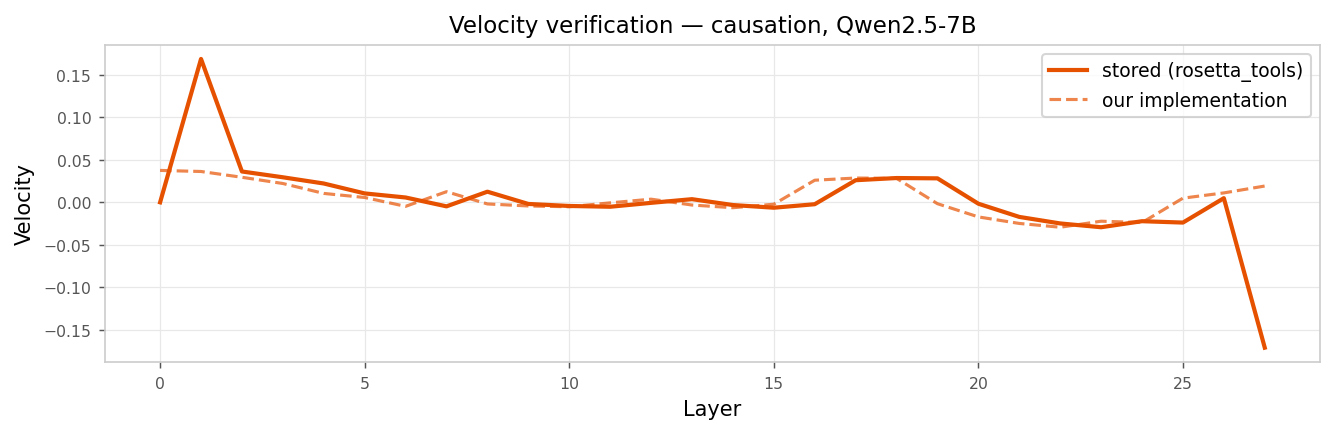

Max absolute difference: 1.90e-01
Note: rosetta_tools uses smoothed np.diff; this is a sliding-window approximation.


In [6]:
def velocity(separations: list, window: int = 3) -> list:
    s = np.array(separations, float)
    pad = window // 2
    # Asymmetric pad: right side gets (window - pad) so s_pad[i+window] stays in bounds
    s_pad = np.pad(s, (pad, window - pad), mode="edge")
    return [(s_pad[i + window] - s_pad[i]) / window for i in range(len(s))]

path = hf_hub_download(
    HF_REPO,
    filename=f"{HF_DATA_ROOT}/Qwen_Qwen2.5_7B/caz_causation.json",
    repo_type="dataset",
)
with open(path) as f:
    caz_ref = json.load(f)

stored_metrics = caz_ref["layer_data"]["metrics"]
stored_sep = [m["separation_fisher"] for m in stored_metrics]
stored_vel = [m["velocity"] for m in stored_metrics]
our_vel = velocity(stored_sep, window=3)

causation_color = concept_color("causation")
fig, ax = plt.subplots(figsize=(9, 3))
fig.patch.set_facecolor("white")
layers = [m["layer"] for m in stored_metrics]
ax.plot(layers, stored_vel, color=causation_color, lw=2, label="stored (rosetta_tools)")
ax.plot(layers, our_vel, color=causation_color, lw=1.5, ls="--", alpha=0.7, label="our implementation")
ax.set_xlabel("Layer")
ax.set_ylabel("Velocity")
ax.set_title("Velocity verification — causation, Qwen2.5-7B")
ax.legend()
apply_theme(ax)
plt.tight_layout()
plt.show()
print(f"Max absolute difference: {max(abs(a-b) for a,b in zip(stored_vel, our_vel)):.2e}")
print("Note: rosetta_tools uses smoothed np.diff; this is a sliding-window approximation.")

## 4. Procrustes alignment

The central question of Paper 4: do different transformer architectures encode concepts in the same geometric directions? If so, we'd expect a single rotation to map one model's concept space onto another's.

The **Orthogonal Procrustes problem** finds exactly this rotation:

$$\min_{R:\, R^T R = I} \| A R - B \|_F \quad \Rightarrow \quad R = V U^T,\quad U \Sigma V^T = \text{SVD}(A^T B)$$

Given calibration activations $A$ (model 1) and $B$ (model 2), $R$ is the rotation that best maps $B$'s coordinate frame into $A$'s.

In [7]:
def procrustes_rotation(source: np.ndarray, target: np.ndarray) -> np.ndarray:
    """Find R s.t. target @ R ≈ source."""
    A = np.asarray(source, float)
    B = np.asarray(target, float)
    A -= A.mean(0); B -= B.mean(0)
    R, _ = orthogonal_procrustes(B, A)  # scipy: finds R minimising ||B@R - A||_F
    return R

def cosine(v1: np.ndarray, v2: np.ndarray) -> float:
    v1, v2 = np.asarray(v1, float), np.asarray(v2, float)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12))

# ── Toy demonstration: known 45° rotation ────────────────────────────────────
rng = np.random.default_rng(0)
theta = np.radians(45)
R_true = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])

# Model A: standard frame
acts_A = rng.normal(0, 1, (60, 2))
true_dir_A = np.array([1.0, 0.0])

# Model B: same concept, coordinate frame rotated 45°
acts_B = acts_A @ R_true
true_dir_B = true_dir_A @ R_true

# Without alignment
print(f"Raw cosine (pre-alignment):      {cosine(true_dir_A, true_dir_B):.4f}  (cos 45° = {np.cos(theta):.4f})")

# Recover rotation and align
R_hat = procrustes_rotation(acts_A, acts_B)
dir_B_aligned = true_dir_B @ R_hat
print(f"Aligned cosine (post-rotation):  {cosine(true_dir_A, dir_B_aligned):.4f}  (expected: 1.0)")

Raw cosine (pre-alignment):      0.7071  (cos 45° = 0.7071)
Aligned cosine (post-rotation):  1.0000  (expected: 1.0)


## 5. The PRH question: do different architectures share a geometric language?

Paper 4 tests this by extracting each concept's dominant direction at its **peak layer** — the layer where Fisher separation $S(l)$ is maximised, identified independently per concept and per model.

The protocol:

1. For each cross-family model pair $(A, B)$ with the same hidden dimension, extract the dominant concept direction at each concept's **peak layer** (argmax $S(l)$)
2. **LOCO fit**: hold out one concept; fit a Procrustes rotation $B \to A$ using the peak-layer directions of the remaining 16 concepts
3. **Test**: rotate the held-out concept's direction and measure cosine similarity to the target model
4. Compare **matched** (same concept) vs **mismatched** (different concept)

**Why cross-family?** Within-family pairs (e.g., Pythia-1.4B vs Pythia-6.9B) share training dynamics that inflate raw cosines to ~0.49. Restricting to cross-family pairs gives a raw baseline of **0.0001** — effectively zero. Post-alignment across 1,596 cross-family same-dimension pairs: **0.9809**.

We demonstrate on `Qwen2.5-7B` × `Gemma-2-9B`: GQA vs alternating attention, different training, different organisations, same hidden dimension (3584). Peak-layer directions come from the CAZ JSON `dom_vector` field — all 17 concepts, ~34 file downloads cached after first run.

*§6 extends to a depth-stratification secondary analysis: does the effect hold at multiple proportional depths?*

In [ ]:
# Qwen2.5-7B vs Gemma-2-9B: genuinely cross-architecture, same hidden dimension
# Qwen uses GQA; Gemma-2 uses alternating local/global attention — different families entirely
PAIR = {
    "model_a": "Qwen/Qwen2.5-7B",      # 28L, 3584-dim, GQA
    "model_b": "google/gemma-2-9b",     # 42L, 3584-dim, alternating attention
}
# All 17 concepts — same set used in Paper 4
TEST_CONCEPTS = [
    "agency", "authorization", "causation", "certainty", "credibility",
    "deception", "exfiltration", "formality", "moral_valence", "negation",
    "plurality", "sarcasm", "sentiment", "specificity", "temporal_order",
    "threat_severity", "urgency",
]

def model_key(model_id: str) -> str:
    return model_id.replace("/", "_").replace("-", "_")

def get_peak_dom_vector(caz_json: dict) -> tuple[np.ndarray, int]:
    """Dominant concept direction at the peak layer (argmax Fisher separation)."""
    metrics = caz_json["layer_data"]["metrics"]
    peak = max(metrics, key=lambda m: m["separation_fisher"])
    return np.array(peak["dom_vector"], dtype=np.float64), peak["layer"]

# Download all concept files for both models; extract peak-layer directions
directions  = {"model_a": {}, "model_b": {}}
peak_layers = {"model_a": {}, "model_b": {}}
for role, model_id in PAIR.items():
    key = model_key(model_id)
    for concept in TEST_CONCEPTS:
        path = hf_hub_download(
            HF_REPO,
            filename=f"{HF_DATA_ROOT}/{key}/caz_{concept}.json",
            repo_type="dataset",
        )
        with open(path) as f:
            caz_data = json.load(f)
        vec, layer = get_peak_dom_vector(caz_data)
        directions[role][concept]  = vec
        peak_layers[role][concept] = layer

# Raw (pre-alignment) cosines — expect near-zero for a cross-family pair
print(f"Cross-family pair:  {PAIR['model_a']}  ×  {PAIR['model_b']}\n")
print(f"{'Concept':22s}  {'Raw cosine':>12s}  {'Peak A':>8s}  {'Peak B':>8s}")
print("-" * 60)
raw_cosines = []
for concept in TEST_CONCEPTS:
    raw = cosine(directions["model_a"][concept], directions["model_b"][concept])
    raw_cosines.append(raw)
    pla = peak_layers["model_a"][concept]
    plb = peak_layers["model_b"][concept]
    print(f"{concept:22s}  {raw:12.4f}  {pla:8d}  {plb:8d}")
print(f"\nMean raw cosine: {np.mean(raw_cosines):.4f}  "
      "(near zero — coordinate frames unrelated before alignment)")

In [9]:
# ── Alternative cross-architecture pairs ─────────────────────────────────────
# All pairs below are same hidden-dim (no PCA projection needed) and cross-family.
# Swap any into PAIR above — the LOCO test code is architecture-agnostic.
#
# SMALL (120–400M, 768-dim) — fast download, good for quick verification
#   PAIR = {"model_a": "openai-community/gpt2",    "model_b": "EleutherAI/pythia-160m"}
#   PAIR = {"model_a": "openai-community/gpt2",    "model_b": "facebook/opt-125m"}
#   PAIR = {"model_a": "EleutherAI/pythia-160m",   "model_b": "facebook/opt-125m"}
#
# MEDIUM (2–3B)
#   # Pythia vs OPT, both 2560-dim, MHA — well-studied pair
#   PAIR = {"model_a": "EleutherAI/pythia-2.8b",   "model_b": "facebook/opt-2.7b"}
#
#   # Pythia vs Phi-2 — EleutherAI vs Microsoft, same dim
#   PAIR = {"model_a": "EleutherAI/pythia-2.8b",   "model_b": "microsoft/phi-2"}
#
#   # Qwen vs Llama — Alibaba vs Meta, both 2048-dim
#   PAIR = {"model_a": "Qwen/Qwen2.5-3B",          "model_b": "meta-llama/Llama-3.2-1B"}
#
# LARGE (7–9B)  ← DEFAULT
#   # Qwen2.5-7B vs Gemma-2-9B — GQA vs alternating attention, both 3584-dim
#   PAIR = {"model_a": "Qwen/Qwen2.5-7B",          "model_b": "google/gemma-2-9b"}  ← DEFAULT
#
#   # Pythia-6.9B vs OPT-6.7B — both 4096-dim, different training
#   PAIR = {"model_a": "EleutherAI/pythia-6.9b",   "model_b": "facebook/opt-6.7b"}
#
#   # Llama-3.1-8B vs Mistral-7B — both 4096-dim, Meta vs Mistral
#   PAIR = {"model_a": "meta-llama/Llama-3.1-8B",  "model_b": "mistralai/Mistral-7B-v0.3"}
#
#   # Llama-3.1-8B vs Pythia-6.9B — 4096-dim, transformer research vs instruction-focused
#   PAIR = {"model_a": "meta-llama/Llama-3.1-8B",  "model_b": "EleutherAI/pythia-6.9b"}
#
# VERY LARGE (12B+)
#   # Pythia-12B vs Qwen2.5-14B — both 5120-dim, cross-family
#   PAIR = {"model_a": "EleutherAI/pythia-12b",    "model_b": "Qwen/Qwen2.5-14B"}
#
#   # Llama-3.1-70B vs Qwen2.5-72B — both 8192-dim, Meta vs Alibaba at scale
#   PAIR = {"model_a": "meta-llama/Llama-3.1-70B", "model_b": "Qwen/Qwen2.5-72B"}

In [ ]:
# LOCO Procrustes test — single peak-layer vector per concept
results = []
for held_concept in TEST_CONCEPTS:
    fit_concepts = [c for c in TEST_CONCEPTS if c != held_concept]

    # Calibration: one peak-layer vector per concept  →  shape (16, hidden_dim)
    cal_a = np.vstack([directions["model_a"][c] for c in fit_concepts])
    cal_b = np.vstack([directions["model_b"][c] for c in fit_concepts])

    R = procrustes_rotation(cal_a, cal_b)   # maps model_b → model_a frame

    dir_a = directions["model_a"][held_concept]
    dir_b = directions["model_b"][held_concept]

    raw_cos     = cosine(dir_a, dir_b)
    matched_cos = cosine(dir_a, dir_b @ R)
    mismatch_cosines = [
        cosine(dir_a, directions["model_b"][oc] @ R) for oc in fit_concepts
    ]
    mismatched_mean = float(np.mean(mismatch_cosines))

    results.append({
        "concept":    held_concept,
        "raw":        raw_cos,
        "matched":    matched_cos,
        "mismatched": mismatched_mean,
        "delta":      matched_cos - mismatched_mean,
    })

# Print table
print(f"{'Concept':22s}  {'Raw':>8s}  {'Matched':>9s}  {'Mismatch':>10s}  {'Δ':>7s}")
print("-" * 65)
for r in results:
    sign = "+" if r["delta"] > 0 else " "
    print(f"{r['concept']:22s}  {r['raw']:8.4f}  {r['matched']:9.4f}  "
          f"{r['mismatched']:10.4f}  {sign}{abs(r['delta']):.4f}")
n_pos = sum(1 for r in results if r["delta"] > 0)
print(f"\nPositive Δ: {n_pos}/{len(results)}")

# Bar chart: raw vs mismatched vs matched, per concept
x      = np.arange(len(results))
w      = 0.25
labels = [r["concept"].replace("_", "\n") for r in results]
raw_v  = [r["raw"]        for r in results]
mat_v  = [r["matched"]    for r in results]
mis_v  = [r["mismatched"] for r in results]

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("white")
ax.bar(x - w, raw_v, w, label="Raw (pre-alignment)",  color="#BDBDBD", alpha=0.85)
ax.bar(x,     mis_v, w, label="Mismatched (aligned)", color="#90CAF9", alpha=0.85)
ax.bar(x + w, mat_v, w, label="Matched (aligned)",
       color=FAMILY_COLORS.get("Pythia", "#1565C0"), alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Cosine similarity")
ax.set_title(
    f"LOCO Procrustes — Qwen2.5-7B × Gemma-2-9B  (peak layers, all 17 concepts)\n"
    f"{n_pos}/{len(results)} concepts: matched > mismatched",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.axhline(0, color=THEME["spine"], lw=0.8)
apply_theme(ax)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.patches as mpatches

# ── Concept-space PCA — what Procrustes rotation actually does ─────────────────
# Full-fit on all 17 (for illustration); LOCO above is the rigorous leave-one-out test.
#
# Steps:
#  1. Stack each model's 17 peak-layer directions into a matrix
#  2. Fit Procrustes (procrustes_rotation centres both matrices before finding R)
#  3. PCA on centred Qwen directions → 2-D reference frame
#  4. Project raw Gemma (centred) → small dot-products with Qwen PCA axes → near origin
#  5. Project aligned Gemma (centred → rotated) → coincides with Qwen points

qwen_mat  = np.vstack([directions["model_a"][c] for c in TEST_CONCEPTS])  # (17, 3584)
gemma_mat = np.vstack([directions["model_b"][c] for c in TEST_CONCEPTS])  # (17, 3584)

# np.vstack returns new arrays — in-place centering inside procrustes_rotation is safe
R_full    = procrustes_rotation(qwen_mat, gemma_mat)
# After the call: qwen_mat and gemma_mat are each mean-centred (modified in-place)

# PCA on centred Qwen
_, S, Vt = np.linalg.svd(qwen_mat, full_matrices=False)
comps = Vt[:2]                              # (2, 3584) — top-2 principal directions
evr   = (S[:2]**2) / (S**2).sum()          # fraction of variance explained

q2d = qwen_mat @ comps.T                   # (17, 2) — Qwen projections
g2d = gemma_mat @ comps.T                  # (17, 2) — raw Gemma (centred → small projections)
r2d = (gemma_mat @ R_full) @ comps.T       # (17, 2) — aligned Gemma (≈ Qwen)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.patch.set_facecolor("white")

for ax, panel_title, g_pts in [
    (axes[0], "Before alignment  (raw coordinate frames)", g2d),
    (axes[1], "After Procrustes rotation", r2d),
]:
    for i, concept in enumerate(TEST_CONCEPTS):
        col = concept_color(concept)
        qx, qy = q2d[i]
        gx, gy = g_pts[i]

        # Dashed line — same concept, different model
        ax.plot([qx, gx], [qy, gy], color=col, lw=1.2, ls="--", alpha=0.45, zorder=2)

        # Qwen: filled circle
        ax.scatter(qx, qy, color=col, s=180, zorder=5,
                   marker="o", edgecolors="white", linewidths=1.5)

        # Gemma: open ring — stays visible even when directly on top of Qwen dot
        ax.scatter(gx, gy, facecolors="none", edgecolors=col, s=300,
                   zorder=4, marker="o", linewidths=2.5)

        # Label at Qwen position
        ax.annotate(
            concept.replace("_", " "),
            (qx, qy), textcoords="offset points", xytext=(8, 3),
            fontsize=7.5, color=col, zorder=6,
        )

    ax.set_title(panel_title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"PC1  ({evr[0]:.0%} of Qwen variance)", fontsize=10)
    ax.set_ylabel(f"PC2  ({evr[1]:.0%} of Qwen variance)", fontsize=10)
    ax.axhline(0, color=THEME["spine"], lw=0.5, alpha=0.3)
    ax.axvline(0, color=THEME["spine"], lw=0.5, alpha=0.3)
    apply_theme(ax)

# Rotation-count annotation on the right panel
axes[1].annotate(
    "1 rotation per model pair\n(same R maps all concepts)",
    xy=(0.97, 0.04), xycoords="axes fraction",
    ha="right", va="bottom", fontsize=9, color=THEME["text"],
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=THEME["spine"],
              alpha=0.85, linewidth=0.8),
)

# Shared legend
leg_q = plt.scatter([], [], color="#555555", s=130, marker="o",
                    edgecolors="white", linewidths=1.5, label="Qwen2.5-7B  (●)")
leg_g = plt.scatter([], [], facecolors="none", edgecolors="#555555", s=200,
                    marker="o", linewidths=2.5, label="Gemma-2-9B  (○)")
fig.legend(handles=[leg_q, leg_g], loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle(
    "All 17 peak-layer concept directions projected into Qwen's 2-D subspace\n"
    "●  Qwen2.5-7B (reference)   ○  Gemma-2-9B   —  dashed lines connect same-concept pairs",
    fontsize=11, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

d_before = np.mean([np.linalg.norm(q2d[i] - g2d[i]) for i in range(len(TEST_CONCEPTS))])
d_after  = np.mean([np.linalg.norm(q2d[i] - r2d[i]) for i in range(len(TEST_CONCEPTS))])
print(f"Mean same-concept pair distance in 2-D: {d_before:.4f}  →  {d_after:.5f}")
print(f"Variance explained: {evr[0]:.1%} + {evr[1]:.1%} = {sum(evr):.1%} of Qwen direction variance")
print(f"\nNote: 1 Procrustes rotation R per model pair, fitted once, applied to all {len(TEST_CONCEPTS)} concepts.")

In [ ]:
# ── PRH alignment gallery — all 17 concepts, 3 additional cross-family pairs ──
# The two-model demo above uses 7 concepts for fast downloads. Here we show all 17
# concepts across three additional cross-family pairs spanning small / medium / large.
# One Procrustes rotation per pair; "after alignment" panels only.
#
# Downloads ~51 files from HF on first run; instant from cache on subsequent runs.
import matplotlib.patches as mpatches

ALL_17_CONCEPTS = [
    "agency", "authorization", "causation", "certainty", "credibility",
    "deception", "exfiltration", "formality", "moral_valence", "negation",
    "plurality", "sarcasm", "sentiment", "specificity", "temporal_order",
    "threat_severity", "urgency",
]

GALLERY_PAIRS = [
    {
        "model_a": "openai-community/gpt2",
        "model_b": "EleutherAI/pythia-160m",
        "label": "GPT-2  ×  Pythia-160m",
        "size":  "small · 768-dim",
        "fam":   "OpenAI vs EleutherAI",
    },
    {
        "model_a": "EleutherAI/pythia-2.8b",
        "model_b": "facebook/opt-2.7b",
        "label": "Pythia-2.8B  ×  OPT-2.7B",
        "size":  "medium · 2560-dim",
        "fam":   "EleutherAI vs Meta",
    },
    {
        "model_a": "meta-llama/Llama-3.1-8B",
        "model_b": "mistralai/Mistral-7B-v0.3",
        "label": "Llama-3.1-8B  ×  Mistral-7B",
        "size":  "large · 4096-dim",
        "fam":   "Meta vs Mistral",
    },
]

def _load_pair_directions(spec, concepts):
    dirs = {"model_a": {}, "model_b": {}}
    for role, model_id in [("model_a", spec["model_a"]), ("model_b", spec["model_b"])]:
        key = model_key(model_id)
        for concept in concepts:
            path = hf_hub_download(
                HF_REPO,
                filename=f"{HF_DATA_ROOT}/{key}/caz_{concept}.json",
                repo_type="dataset",
            )
            with open(path) as f:
                caz_data = json.load(f)
            dirs[role][concept], _ = get_peak_dom_vector(caz_data)
    return dirs

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor("white")

for ax, spec in zip(axes, GALLERY_PAIRS):
    dirs = _load_pair_directions(spec, ALL_17_CONCEPTS)

    mat_a = np.vstack([dirs["model_a"][c] for c in ALL_17_CONCEPTS])
    mat_b = np.vstack([dirs["model_b"][c] for c in ALL_17_CONCEPTS])
    R     = procrustes_rotation(mat_a, mat_b)  # centres both in-place

    _, S, Vt = np.linalg.svd(mat_a, full_matrices=False)
    comps = Vt[:2]
    evr   = (S[:2]**2) / (S**2).sum()

    a2d = mat_a @ comps.T
    b2d = (mat_b @ R) @ comps.T   # aligned model_b projected into model_a's 2-D frame

    for i, concept in enumerate(ALL_17_CONCEPTS):
        col = concept_color(concept)
        ax.plot([a2d[i, 0], b2d[i, 0]], [a2d[i, 1], b2d[i, 1]],
                color=col, lw=1.2, ls="--", alpha=0.4, zorder=2)
        ax.scatter(*a2d[i], color=col, s=160, zorder=5,
                   marker="o", edgecolors="white", linewidths=1.2)
        ax.scatter(*b2d[i], facecolors="none", edgecolors=col, s=260,
                   zorder=4, marker="o", linewidths=2.2)

    ax.axhline(0, color=THEME["spine"], lw=0.4, alpha=0.25)
    ax.axvline(0, color=THEME["spine"], lw=0.4, alpha=0.25)
    apply_theme(ax)

    ax.set_title(
        f"{spec['label']}\n{spec['size']}  ·  {spec['fam']}",
        fontsize=9.5, fontweight="bold", pad=8,
    )
    ax.set_xlabel(f"PC1  ({evr[0]:.0%} of model A variance)", fontsize=9)
    ax.set_ylabel(f"PC2  ({evr[1]:.0%} of model A variance)", fontsize=9)

    raw_cos     = float(np.mean([cosine(dirs["model_a"][c], dirs["model_b"][c])
                                 for c in ALL_17_CONCEPTS]))
    matched_cos = float(np.mean([cosine(dirs["model_a"][c], dirs["model_b"][c] @ R)
                                 for c in ALL_17_CONCEPTS]))
    ax.annotate(
        f"raw → aligned:  {raw_cos:.3f} → {matched_cos:.3f}",
        xy=(0.5, 0.025), xycoords="axes fraction",
        ha="center", va="bottom", fontsize=8.5, color=THEME["text"],
        bbox=dict(boxstyle="round,pad=0.28", facecolor="white",
                  edgecolor=THEME["spine"], alpha=0.88, linewidth=0.7),
    )

# Concept legend — one patch per concept, 9 per row
legend_patches = [
    mpatches.Patch(color=concept_color(c), label=c.replace("_", " "))
    for c in ALL_17_CONCEPTS
]
fig.legend(
    handles=legend_patches,
    loc="lower center", ncol=9, fontsize=8,
    bbox_to_anchor=(0.5, -0.10), frameon=False,
    title="concepts  ·  ● = model A  ○ = model B  (same-concept pairs connected by dashed lines)",
    title_fontsize=8.5,
)
fig.suptitle(
    "PRH alignment gallery — all 17 concepts across 3 cross-family pairs\n"
    "After 1 Procrustes rotation per model pair, all concept directions coincide",
    fontsize=11, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.12, 1, 0.93])
plt.show()

## 6. Reproduce Paper 4: primary result and depth-stratification

The two-model demo above shows the LOCO protocol on a single cross-family pair. Paper 4 runs this at scale across all same-dimension model pairs in the dataset.

**Primary result (peak-layer, cross-family only):** 33 models, 8 families, 17 concepts, 1,596 cross-family same-dimension pairs. Mean aligned cosine **0.9809** from a raw baseline of 0.0001. The bar chart directly below shows this alongside null distributions.

**Depth-stratification (secondary analysis):** Does matched > mismatched hold at multiple proportional depths — not just the peak layer? This analysis runs on all 563 same-dimension pairs (not cross-family restricted). Mean matched 0.3531 vs mismatched 0.1989, Δ = +0.154, 563/563 positive.

The pre-computed depth-stratification results are in `data/prh_p5_samedim_n250.json`.

In [ ]:
# Load pre-computed p5 results
data_path = Path("../data/prh_p5_samedim_n250.json")
if not data_path.exists():
    # Fallback: try current directory (e.g. when running from repo root)
    data_path = Path("data/prh_p5_samedim_n250.json")

with open(data_path) as f:
    p5 = json.load(f)

summary = p5["summary"]["grand"]
pair_results = p5["pair_results"]

print(f"N observations:    {summary['n_observations']}")
print(f"N positive delta:  {summary['n_positive_delta']} / {summary['n_observations']}")
print(f"Mean matched:      {summary['mean_matched']:.4f}")
print(f"Mean mismatched:   {summary['mean_mismatched']:.4f}")
print(f"Mean delta:        {summary['mean_delta']:.4f}")
print(f"Mann-Whitney p:    {summary['mannwhitney_p']:.2e}")
print(f"Bootstrap 95% CI:  [{summary['bootstrap_ci_95'][0]:.4f}, {summary['bootstrap_ci_95'][1]:.4f}]")

In [ ]:
# ── Primary PRH result — Paper 4 (Henry 2026d) ──────────────────────────────
# Peak-layer LOCO, cross-family pairs only:
#   33 models · 8 families · 17 concepts · 1,596 cross-family same-dimension pairs
#
# Within-family pairs share training dynamics → raw cosine ≈ 0.487 (inflated).
# Cross-family restriction gives an honest near-zero baseline.

PRIMARY = {
    "Cross-family\nraw":        0.0001,
    "Permuted-family\nnull":    0.0032,
    "Random-text\nnull":        0.1648,
    "Cross-family\naligned":    0.9809,
}
_bar_colors = ["#BDBDBD", "#CFD8DC", "#90CAF9", FAMILY_COLORS.get("Pythia", "#1565C0")]
_hatches    = [None, "///", "///", None]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
bars = ax.bar(
    range(len(PRIMARY)), list(PRIMARY.values()),
    color=_bar_colors, alpha=0.9, width=0.55,
)
for bar, hatch in zip(bars, _hatches):
    if hatch:
        bar.set_hatch(hatch)
        bar.set_edgecolor("#999999")
ax.set_xticks(range(len(PRIMARY)))
ax.set_xticklabels(list(PRIMARY.keys()), fontsize=10)
ax.set_ylabel("Mean cosine similarity", fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_title(
    "PRH primary result — peak-layer alignment across architectures\n"
    "N = 1,596 cross-family same-dimension pairs  |  33 models · 8 families · 17 concepts",
    fontsize=11,
)
for bar, val in zip(bars, PRIMARY.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.018,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.axhline(0, color=THEME["spine"], lw=0.8)
ax.annotate(
    "Within-family raw ≈ 0.487\n(training dynamics inflate;\ncross-family = honest baseline)",
    xy=(0, 0.0001), xytext=(0.55, 0.38),
    fontsize=8.5, color=THEME["text"],
    arrowprops=dict(arrowstyle="->", color=THEME["spine"], lw=0.8),
)
apply_theme(ax)
plt.tight_layout()
plt.show()
print("Source: Henry 2026d, §4 — N=1,596 cross-family same-dim pairs, peak-layer LOCO protocol")

In [ ]:
# ── Per-concept alignment spread — all 17 concepts ───────────────────────────
# Loads the primary alignment CSV (shipped with this repo).
# Each row: one (concept, model-pair) aligned cosine, cross-family same-dim only.
# Strip chart (left): distribution of aligned cosines per concept, sorted tight→loose.
# Std bars (right):   centroid spread — how consistent is alignment across pairs?
import csv

def _model_family(model_id):
    m = model_id.lower()
    if "pythia" in m or "gpt-neo" in m: return "EleutherAI"
    if "opt" in m and "facebook" in m:  return "Meta-OPT"
    if "llama" in m:                    return "Meta-Llama"
    if "qwen" in m:                     return "Qwen"
    if "gemma" in m:                    return "Google"
    if "mistral" in m or "mixtral" in m: return "Mistral"
    if "gpt2" in m or "gpt-2" in m:    return "OpenAI"
    if "phi" in m:                      return "Microsoft"
    if "falcon" in m:                   return "TII"
    return "other"

csv_path = Path("../data/alignment_results_samedim_n250.csv")
if not csv_path.exists():
    csv_path = Path("data/alignment_results_samedim_n250.csv")

with open(csv_path) as f:
    prim_rows = list(csv.DictReader(f))

cross_fam = [
    r for r in prim_rows
    if r["is_same_dim"] == "True"
    and _model_family(r["source_model"]) != _model_family(r["target_model"])
]

from collections import defaultdict
c_vals = defaultdict(list)
for r in cross_fam:
    c_vals[r["concept"]].append(float(r["aligned_cosine"]))

# Sort tight → loose (ascending std)
concept_order_prim = sorted(c_vals, key=lambda c: np.std(c_vals[c]))

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.patch.set_facecolor("white")
_rng = np.random.default_rng(42)

# Left: strip chart — individual pair cosines, jittered vertically
ax = axes[0]
for y_idx, c in enumerate(concept_order_prim):
    vals = np.array(c_vals[c])
    col  = concept_color(c)
    jitter = _rng.uniform(-0.30, 0.30, len(vals))
    ax.scatter(vals, y_idx + jitter, color=col, alpha=0.30, s=14, linewidths=0, zorder=2)
    ax.scatter(vals.mean(), y_idx, color=col, s=90, marker="D",
               edgecolors="white", linewidths=1.0, zorder=5)

ax.set_yticks(range(len(concept_order_prim)))
ax.set_yticklabels([c.replace("_", " ") for c in concept_order_prim], fontsize=9)
ax.set_xlabel("Aligned cosine  (cross-family, same-dim pairs)", fontsize=11)
ax.set_title(f"Per-concept distribution  (N≈102 pairs each  ·  ◆ = mean)", fontsize=11)
ax.set_xlim(0.60, 1.01)
ax.axvline(1.0, color=THEME["spine"], lw=0.7, ls="--", alpha=0.35)
apply_theme(ax)

# Right: std bar chart
ax = axes[1]
stds   = [np.std(c_vals[c])  for c in concept_order_prim]
means  = [np.mean(c_vals[c]) for c in concept_order_prim]
colors = [concept_color(c)   for c in concept_order_prim]
bars   = ax.barh(range(len(concept_order_prim)), stds, color=colors, alpha=0.85)

# Annotate mean value at end of each bar
for y_idx, (std, mean) in enumerate(zip(stds, means)):
    ax.text(std + 0.001, y_idx, f"{mean:.4f}", va="center", fontsize=7.5,
            color=THEME["text"])

ax.set_yticks(range(len(concept_order_prim)))
ax.set_yticklabels([c.replace("_", " ") for c in concept_order_prim], fontsize=9)
ax.set_xlabel("Std of aligned cosine across model pairs", fontsize=11)
ax.set_title("Centroid spread — consistency across pairs\n(mean aligned cosine annotated)", fontsize=11)
ax.axvline(0, color=THEME["spine"], lw=0.8)
apply_theme(ax)

fig.suptitle(
    "Primary PRH result — per-concept alignment spread  (all 17 concepts)\n"
    "Cross-family same-dim pairs  ·  sorted tight → loose",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

print("Centroid spread (sorted tight → loose):")
print(f"  {'':2s} {'Concept':22s}  {'Mean':>8s}  {'Std':>8s}  {'Min':>8s}  {'N':>5s}")
print("  " + "─" * 58)
for c in concept_order_prim:
    v   = np.array(c_vals[c])
    tag = "★" if v.std() < 0.01 else ("⚠" if v.std() > 0.05 else " ")
    print(f"  {tag} {c:22s}  {v.mean():8.4f}  {v.std():8.4f}  {v.min():8.4f}  {len(v):5d}")

In [ ]:
# Depth-stratification: concept-stratified scatter and sorted delta bars
# pair_results has one entry per (concept, model-pair): 1,358 total
from collections import defaultdict
from matplotlib.patches import Ellipse

def _concept_ellipse(ax, x_arr, y_arr, color, n_std=1.5, alpha=0.13):
    """Draw a 1.5-sigma covariance ellipse around a concept cluster."""
    if len(x_arr) < 4:
        return
    cov = np.cov(x_arr, y_arr)
    evals, evecs = np.linalg.eigh(cov)
    order  = evals.argsort()[::-1]
    evals, evecs = evals[order], evecs[:, order]
    angle  = np.degrees(np.arctan2(*evecs[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(max(evals[0], 0))
    height = 2 * n_std * np.sqrt(max(evals[1], 0))
    el = Ellipse(
        xy=(float(np.mean(x_arr)), float(np.mean(y_arr))),
        width=width, height=height, angle=angle,
        facecolor=color, alpha=alpha,
        edgecolor=color, linewidth=1.2, linestyle=":",
        zorder=3,
    )
    ax.add_patch(el)

matched_means    = [pr["matched_mean"]    for pr in pair_results]
mismatched_means = [pr["mismatched_mean"] for pr in pair_results]
concepts_list    = [pr["test_concept"]    for pr in pair_results]

# Sort delta while retaining concept label
sorted_triples  = sorted(zip([pr["obs_delta"] for pr in pair_results], concepts_list))
deltas_sorted   = [x[0] for x in sorted_triples]
concepts_sorted = [x[1] for x in sorted_triples]

# Per-concept aggregates (for diamond markers + ellipses + legend order)
c_agg = defaultdict(lambda: {"m": [], "mm": [], "d": []})
for m, mm, d, c in zip(matched_means, mismatched_means,
                        [pr["obs_delta"] for pr in pair_results], concepts_list):
    c_agg[c]["m"].append(m); c_agg[c]["mm"].append(mm); c_agg[c]["d"].append(d)

concept_order = sorted(c_agg, key=lambda c: np.mean(c_agg[c]["d"]), reverse=True)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Depth-stratified PRH (secondary) — 1,358 concept × model-pair observations  ·  all Δ > 0",
    fontsize=12, fontweight="bold",
)

# Left: scatter matched vs mismatched, coloured by concept
ax = axes[0]
lim = max(max(matched_means), max(mismatched_means)) * 1.08
ax.plot([0, lim], [0, lim], color=THEME["spine"], lw=1.2, ls="--", zorder=1)

for m, mm, c in zip(matched_means, mismatched_means, concepts_list):
    ax.scatter(mm, m, alpha=0.22, s=10, color=concept_color(c), linewidths=0, zorder=2)

# 1.5-sigma ellipses per concept
for c in concept_order:
    _concept_ellipse(ax, np.array(c_agg[c]["mm"]), np.array(c_agg[c]["m"]), concept_color(c))

# Per-concept mean as filled diamond
for c in concept_order:
    col = concept_color(c)
    ax.scatter(np.mean(c_agg[c]["mm"]), np.mean(c_agg[c]["m"]),
               color=col, s=100, zorder=5, marker="D",
               edgecolors="white", linewidths=1.2,
               label=c.replace("_", " "))

n_above = sum(1 for m, mm in zip(matched_means, mismatched_means) if m > mm)
ax.set_xlabel("Mismatched cosine (aligned)", fontsize=11)
ax.set_ylabel("Matched cosine (aligned)", fontsize=11)
ax.set_title(f"{n_above}/{len(matched_means)} pairs above diagonal  (◆ = centroid, ellipse = 1.5σ)", fontsize=11)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(fontsize=8, loc="lower right", title="concept  ◆ = centroid")
apply_theme(ax)

# Right: sorted delta bars, coloured by concept
ax = axes[1]
bar_colors = [concept_color(c) for c in concepts_sorted]
ax.bar(range(len(deltas_sorted)), deltas_sorted, color=bar_colors, alpha=0.85, linewidth=0)
ax.axhline(np.mean(deltas_sorted), color="#E53935", lw=1.5, ls="--",
           label=f"Mean Δ = {np.mean(deltas_sorted):.3f}")
ax.axhline(0, color=THEME["spine"], lw=0.8)
ax.set_xlabel("Observation rank (sorted by Δ)", fontsize=11)
ax.set_ylabel("Δ = matched − mismatched cosine", fontsize=11)
ax.set_title(f"All {len(deltas_sorted)} observations positive", fontsize=11)

seen = {}
for c in concepts_sorted:
    if c not in seen: seen[c] = concept_color(c)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=seen[c], label=c.replace("_", " "))
    for c in concept_order if c in seen
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper left", title="concept")
apply_theme(ax)

plt.tight_layout()
plt.show()

# ── Centroid-distance report ───────────────────────────────────────────────────
# Distance from each observation to its concept centroid in (mismatched, matched) space.
# Tight clusters → consistent geometry across pairs → high-quality RCP probes.
# Wide clusters → variance in alignment by pair → likely noisier concept pairs.
print("Per-concept centroid spread  (Euclidean distance in matched×mismatched space):")
print(f"  {'Concept':22s}  {'Mean Δ':>8s}  {'Centroid dist':>14s}  {'Spread (std)':>13s}  {'N':>5s}")
print("  " + "─" * 68)
for c in concept_order:
    mm_arr = np.array(c_agg[c]["mm"])
    m_arr  = np.array(c_agg[c]["m"])
    cx, cy = mm_arr.mean(), m_arr.mean()
    dists  = np.sqrt((mm_arr - cx)**2 + (m_arr - cy)**2)
    mean_d = float(np.mean(dists))
    std_d  = float(np.std(dists))
    mean_delta = float(np.mean(c_agg[c]["d"]))
    tag = "★ tight" if mean_d < 0.05 else ("  loose" if mean_d > 0.09 else "       ")
    print(f"  {c:22s}  {mean_delta:8.4f}  {mean_d:14.4f}  {std_d:13.4f}  {len(dists):5d}  {tag}")

## Summary

From first principles to published results:

| Step | What we built |
|------|---------------|
| Fisher separation | Centroid distance normalised by within-class scatter |
| Coherence | Mean cosine similarity to class centroid — directional consistency |
| Velocity | Finite-difference derivative — rate of concept construction |
| Procrustes rotation | SVD-based orthogonal alignment between activation spaces |
| LOCO test | Hold-out evaluation: fit rotation on 16 peak-layer directions, test on the 17th |
| Primary result | 0.0001 → **0.9809** aligned cosine; N = 1,596 cross-family same-dim pairs |
| Concept spread | certainty/sarcasm (σ=0.004) tight; exfiltration/specificity (σ=0.06–0.07) loose |
| Depth-stratification | 563/563 model pairs: matched > mismatched at multiple depths; mean Δ = +0.154 |

The primary result says: a single orthogonal rotation maps one architecture's peak-layer concept directions onto another's with 0.9809 mean cosine similarity — starting from a near-zero raw baseline. The same semantic geometry emerges independently across different model families, training pipelines, and scales.

Removing the two highest-delta concepts (moral_valence, sentiment) moves the headline by only **−0.0016** (0.9809 → 0.9792), confirming the result is not driven by easy affective concepts. The weakest-aligning concepts (exfiltration, specificity, deception) are the safety-critical ones — likely reflecting probe quality constraints rather than geometric absence.

---

| Paper | |
|-------|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 4 — Cross-architecture PRH | [Henry 2026d](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |
| Concept pairs dataset | [Rosetta_Concept_Pairs](https://github.com/jamesrahenry/Rosetta_Concept_Pairs) |